# iNKT Scanpy preprocessing, plotting, and trajectory workflow

This notebook applies the current Scanpy tutorial workflow style to the local iNKT raw 10x matrices extracted from `input.zip`.

It runs:

- raw 10x matrix ingestion across six samples
- sample, condition, and tissue metadata assignment
- gene-expression and multiplexing-capture feature handling
- QC, filtering, normalization, HVG selection, PCA, neighbors, UMAP, and Leiden clustering
- core marker plotting and marker ranking
- PAGA, diffusion map, and DPT pseudotime

The trajectory analysis is exploratory. The DPT root is selected from the cluster with high `Cd27` and low `Itgam` when both markers are present.


In [1]:
from __future__ import annotations

import json
import re
from pathlib import Path

import anndata as ad
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
from scipy.stats import spearmanr
from IPython.display import Image, display

from notebooks.scripts.iNKT.inkt_palette import (
    SAMPLE_LOAD_ORDER,
    TISSUE_MAP,
    configure_inkt_palettes,
    palette_state,
)

ROOT = Path.cwd()
INPUT_ROOT = ROOT / "input/iNKT/data"
RUN_DIR = ROOT / "output/iNKT_scanpy_tutorial_run"
FIG_DIR = RUN_DIR / "figures"
TABLE_DIR = RUN_DIR / "tables"
PROCESSED_H5AD = RUN_DIR / "inkt_scanpy_tutorial_processed.h5ad"

for path in (RUN_DIR, FIG_DIR, TABLE_DIR):
    path.mkdir(parents=True, exist_ok=True)

sc.settings.verbosity = 2
sc.settings.figdir = FIG_DIR
sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False)
np.random.seed(0)


def show_saved(path):
    display(Image(filename=str(path)))


def save_and_show(path, *, dpi=160, bbox_inches="tight"):
    if bbox_inches is None:
        plt.savefig(path, dpi=dpi)
    else:
        plt.savefig(path, dpi=dpi, bbox_inches=bbox_inches)
    plt.close("all")
    show_saved(path)


print("scanpy", sc.__version__)
print("input", INPUT_ROOT)


scanpy 1.12.1
input /home/zzz0054/bio3/input/iNKT/data


/tmp/ipykernel_2918178/1350129522.py:37: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False)
/tmp/ipykernel_2918178/1350129522.py:54: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("scanpy", sc.__version__)


## Discover and load iNKT samples

Each sample directory contains a 10x-style `sample_feature_bc_matrix`. We load all feature types so multiplexing-capture hashtag counts can be summarized, then continue the RNA workflow on gene-expression features.


In [2]:
def parse_sample(sample: str) -> dict[str, str]:
    condition, tissue_token = sample.split("_", 1)
    return {
        "sample": sample,
        "condition": condition,
        "tissue": TISSUE_MAP.get(tissue_token, tissue_token),
    }


sample_paths = {
    sample: INPUT_ROOT / sample / "sample_feature_bc_matrix"
    for sample in SAMPLE_LOAD_ORDER
}
missing = [str(path) for path in sample_paths.values() if not path.exists()]
if missing:
    raise FileNotFoundError("Missing iNKT matrix directories: " + ", ".join(missing))

sample_paths


{'Ctrl_BM': PosixPath('/home/zzz0054/bio3/input/iNKT/data/Ctrl_BM/sample_feature_bc_matrix'),
 'Ctrl_Spleen': PosixPath('/home/zzz0054/bio3/input/iNKT/data/Ctrl_Spleen/sample_feature_bc_matrix'),
 'Ctrl_Thymus': PosixPath('/home/zzz0054/bio3/input/iNKT/data/Ctrl_Thymus/sample_feature_bc_matrix'),
 'T2_BM': PosixPath('/home/zzz0054/bio3/input/iNKT/data/T2_BM/sample_feature_bc_matrix'),
 'T2_Spleen': PosixPath('/home/zzz0054/bio3/input/iNKT/data/T2_Spleen/sample_feature_bc_matrix'),
 'T2_Thymus': PosixPath('/home/zzz0054/bio3/input/iNKT/data/T2_Thymus/sample_feature_bc_matrix')}

In [3]:
def safe_obs_name(value: str) -> str:
    return re.sub(r"[^0-9A-Za-z]+", "_", value).strip("_").lower()


adatas = []
feature_summaries = []
capture_summaries = []

for sample, matrix_dir in sample_paths.items():
    meta = parse_sample(sample)
    sample_all = sc.read_10x_mtx(
        matrix_dir,
        var_names="gene_symbols",
        make_unique=True,
        cache=False,
        gex_only=False,
    )
    sample_all.obs_names = [f"{sample}_{barcode}" for barcode in sample_all.obs_names]
    for key, value in meta.items():
        sample_all.obs[key] = value

    feature_types = sample_all.var.get("feature_types")
    if feature_types is None:
        is_gene = np.ones(sample_all.n_vars, dtype=bool)
        is_capture = np.zeros(sample_all.n_vars, dtype=bool)
    else:
        feature_types = feature_types.astype(str)
        is_gene = feature_types.eq("Gene Expression").to_numpy()
        is_capture = ~is_gene

    feature_counts = (
        feature_types.value_counts().to_dict()
        if feature_types is not None
        else {"unknown": int(sample_all.n_vars)}
    )
    feature_summaries.append(
        {
            **meta,
            "n_cells": int(sample_all.n_obs),
            "n_features": int(sample_all.n_vars),
            **{f"features_{k}": int(v) for k, v in feature_counts.items()},
        }
    )

    if is_capture.any():
        capture = sample_all[:, is_capture].copy()
        capture_matrix = capture.X.toarray() if sp.issparse(capture.X) else np.asarray(capture.X)
        for idx, feature in enumerate(capture.var_names.astype(str)):
            sample_all.obs[f"capture_{safe_obs_name(feature)}_counts"] = capture_matrix[:, idx].astype(float)
            capture_summaries.append(
                {
                    **meta,
                    "feature": str(feature),
                    "total_counts": float(capture_matrix[:, idx].sum()),
                    "mean_counts": float(capture_matrix[:, idx].mean()),
                    "detected_cells": int((capture_matrix[:, idx] > 0).sum()),
                }
            )

    rna = sample_all[:, is_gene].copy()
    rna.var_names_make_unique()
    adatas.append(rna)

adata = ad.concat(adatas, join="outer", merge="first", index_unique=None)
configure_inkt_palettes(adata)
adata.var_names_make_unique()
adata.layers["counts"] = adata.X.copy()

pd.DataFrame(feature_summaries).to_csv(TABLE_DIR / "input_feature_summary_by_sample.csv", index=False)
if capture_summaries:
    pd.DataFrame(capture_summaries).to_csv(TABLE_DIR / "multiplexing_capture_summary.csv", index=False)

input_summary = {
    "shape_raw_gene_expression": [int(adata.n_obs), int(adata.n_vars)],
    "samples": list(SAMPLE_LOAD_ORDER),
    "sample_counts": adata.obs["sample"].astype(str).value_counts().sort_index().to_dict(),
    "condition_counts": adata.obs["condition"].astype(str).value_counts().sort_index().to_dict(),
    "tissue_counts": adata.obs["tissue"].astype(str).value_counts().sort_index().to_dict(),
    "palettes": palette_state(adata),
    "feature_summaries": feature_summaries,
    "capture_features": sorted({row["feature"] for row in capture_summaries}),
}
(TABLE_DIR / "input_summary.json").write_text(json.dumps(input_summary, indent=2, sort_keys=True, allow_nan=False) + "\n")

print(json.dumps(input_summary, indent=2)[:4000])
adata


{
  "shape_raw_gene_expression": [
    18458,
    32285
  ],
  "samples": [
    "Ctrl_BM",
    "Ctrl_Spleen",
    "Ctrl_Thymus",
    "T2_BM",
    "T2_Spleen",
    "T2_Thymus"
  ],
  "sample_counts": {
    "Ctrl_BM": 3998,
    "Ctrl_Spleen": 3829,
    "Ctrl_Thymus": 2101,
    "T2_BM": 3131,
    "T2_Spleen": 3760,
    "T2_Thymus": 1639
  },
  "condition_counts": {
    "Ctrl": 9928,
    "T2": 8530
  },
  "tissue_counts": {
    "bone_marrow": 7129,
    "spleen": 7589,
    "thymus": 3740
  },
  "palettes": {
    "sample": {
      "categories": [
        "Ctrl_Thymus",
        "Ctrl_BM",
        "Ctrl_Spleen",
        "T2_Thymus",
        "T2_BM",
        "T2_Spleen"
      ],
      "colors": [
        "#0000FF",
        "#FFFF00",
        "#FF0000",
        "#00008B",
        "#FFA500",
        "#8B0000"
      ]
    },
    "condition": {
      "categories": [
        "Ctrl",
        "T2"
      ],
      "colors": [
        "#A6A6A6",
        "#4D4D4D"
      ]
    },
    "tissue": {
      "cat

AnnData object with n_obs × n_vars = 18458 × 32285
    obs: 'sample', 'condition', 'tissue', 'capture_thymus_counts', 'capture_bm_counts', 'capture_spleen_counts'
    var: 'gene_ids', 'feature_types'
    uns: 'sample_colors', 'condition_colors', 'tissue_colors'
    layers: 'counts'

## QC, filtering, and normalization

This section follows the Scanpy preprocessing tutorial on raw counts. Raw counts are preserved in `adata.layers["counts"]`; downstream expression values are normalized to 10,000 counts per cell and log-transformed.


filtered out 16544 genes that are detected in less than 3 cells


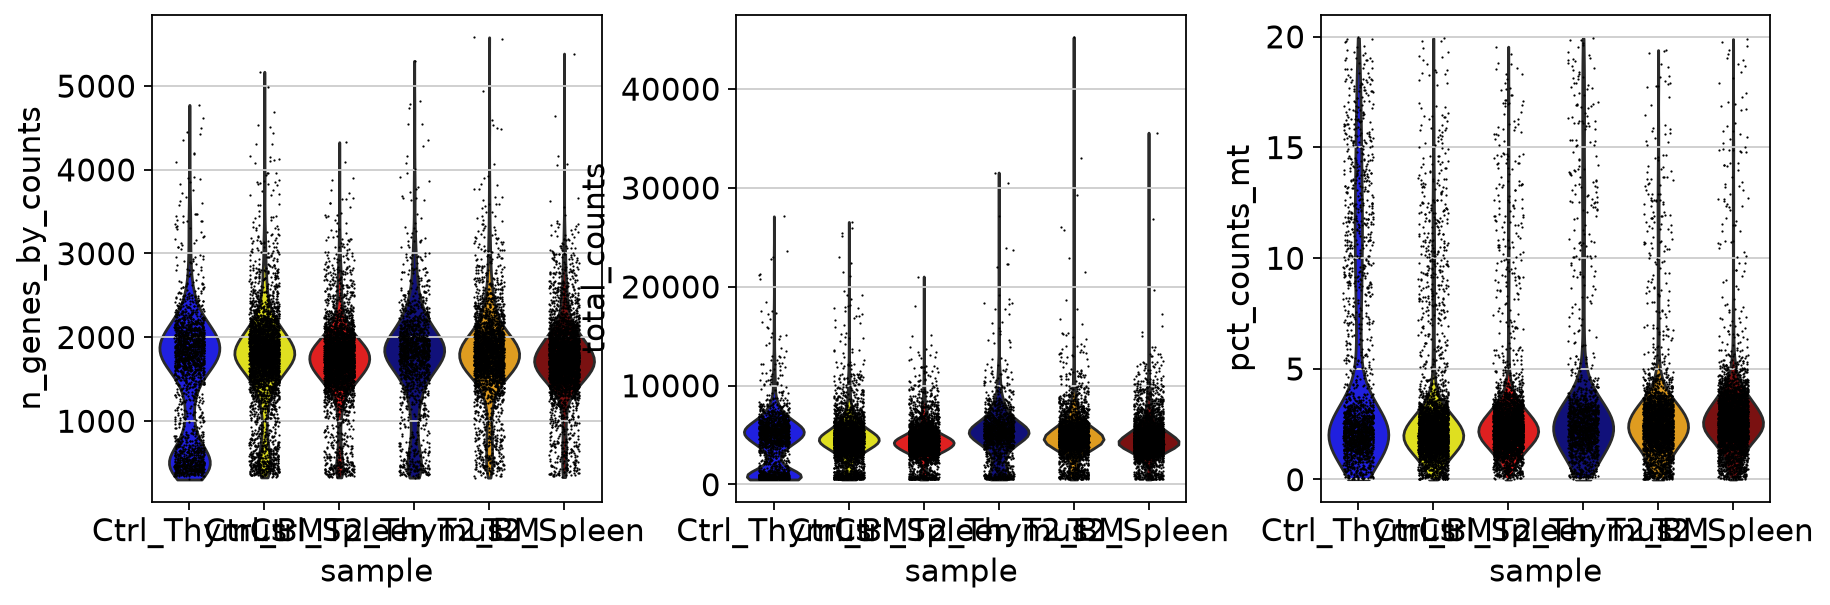

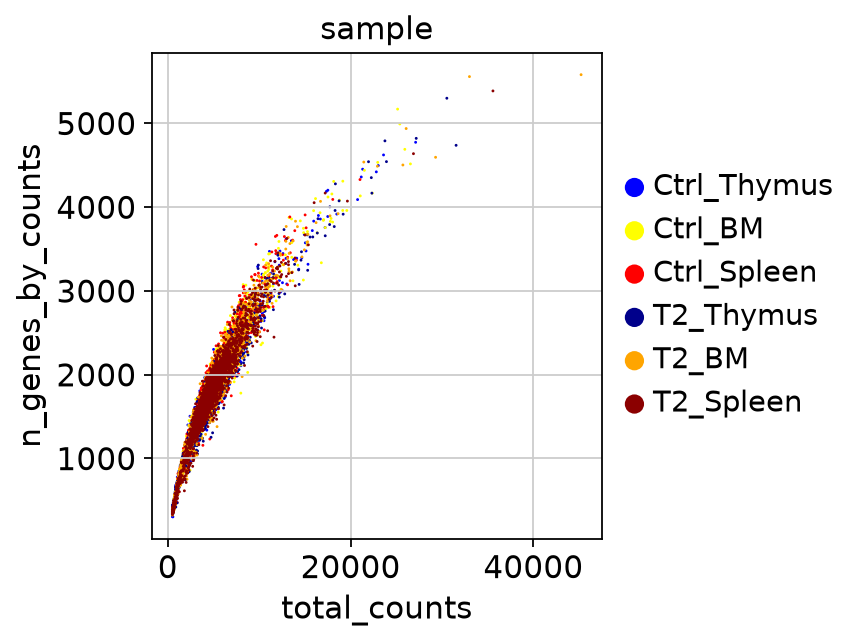

{
  "pre_filter": {
    "n_obs": 18458,
    "n_vars": 32285,
    "min_genes_by_counts": 200,
    "max_pct_counts_mt": 20.0,
    "min_cells_per_gene": 3
  },
  "post_filter": {
    "n_obs": 18204,
    "n_vars": 15741
  }
}
                                  n_genes_by_counts                           \
                                              count         mean         std   
condition tissue      sample                                                   
Ctrl      thymus      Ctrl_Thymus            2033.0  1518.122971  748.803194   
          bone_marrow Ctrl_BM                3978.0  1732.028909  578.128314   
          spleen      Ctrl_Spleen            3808.0  1720.576943  468.542123   
T2        thymus      T2_Thymus              1553.0  1749.876368  648.075409   
          bone_marrow T2_BM                  3095.0  1787.592892  521.512436   

                                                                           \
                                     min     25%     50%    

In [4]:
adata.var["mt"] = adata.var_names.str.startswith(("mt-", "MT-"))
adata.var["ribo"] = adata.var_names.str.startswith(("Rps", "Rpl", "RPS", "RPL"))
adata.var["hb"] = adata.var_names.str.match(r"^(Hb[ab]|HBA|HBB)")

sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt", "ribo", "hb"],
    percent_top=None,
    log1p=False,
    inplace=True,
)

pre_filter = {
    "n_obs": int(adata.n_obs),
    "n_vars": int(adata.n_vars),
    "min_genes_by_counts": 200,
    "max_pct_counts_mt": 20.0,
    "min_cells_per_gene": 3,
}

cell_mask = (adata.obs["n_genes_by_counts"] >= 200) & (adata.obs["pct_counts_mt"] < 20)
adata = adata[cell_mask].copy()
sc.pp.filter_genes(adata, min_cells=3)
post_filter = {"n_obs": int(adata.n_obs), "n_vars": int(adata.n_vars)}

qc_cols = [
    "n_genes_by_counts",
    "total_counts",
    "pct_counts_mt",
    "pct_counts_ribo",
    "pct_counts_hb",
]
qc_summary = adata.obs.groupby(["condition", "tissue", "sample"], observed=True)[qc_cols].describe()
qc_summary.to_csv(TABLE_DIR / "qc_summary_by_condition_tissue_sample.csv")

sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    groupby="sample",
    jitter=0.2,
    multi_panel=True,
    show=False,
)
save_and_show(FIG_DIR / "qc_violin_by_sample.png", dpi=160, bbox_inches="tight")

sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts", color="sample", show=False)
save_and_show(FIG_DIR / "qc_scatter_counts_genes_sample.png", dpi=160, bbox_inches="tight")

filter_summary = {"pre_filter": pre_filter, "post_filter": post_filter}
(TABLE_DIR / "filter_summary.json").write_text(json.dumps(filter_summary, indent=2, sort_keys=True, allow_nan=False) + "\n")

print(json.dumps(filter_summary, indent=2))
print(qc_summary.head())


normalizing counts per cell


    finished (0:00:04)


extracting highly variable genes


    finished (0:00:04)


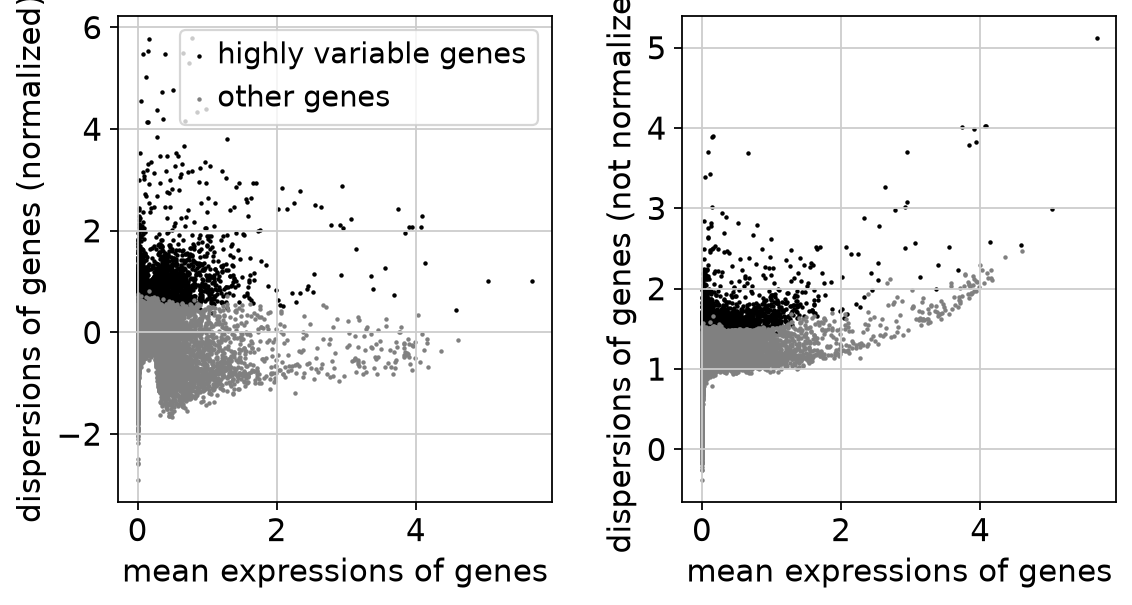

HVG count: 3000


In [5]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata.copy()

sc.pp.highly_variable_genes(
    adata,
    n_top_genes=3000,
    batch_key="sample",
    flavor="seurat",
)
hvg_table = adata.var[
    [
        "highly_variable",
        "means",
        "dispersions",
        "dispersions_norm",
        "highly_variable_nbatches",
        "highly_variable_intersection",
    ]
].copy()
hvg_table.to_csv(TABLE_DIR / "highly_variable_genes.csv")

sc.pl.highly_variable_genes(adata, show=False)
save_and_show(FIG_DIR / "highly_variable_genes.png", dpi=160, bbox_inches="tight")

n_hvg = int(adata.var["highly_variable"].sum())
print("HVG count:", n_hvg)


## PCA, neighborhood graph, UMAP, and Leiden clusters


computing PCA


    with n_comps=50


    finished (0:00:04)


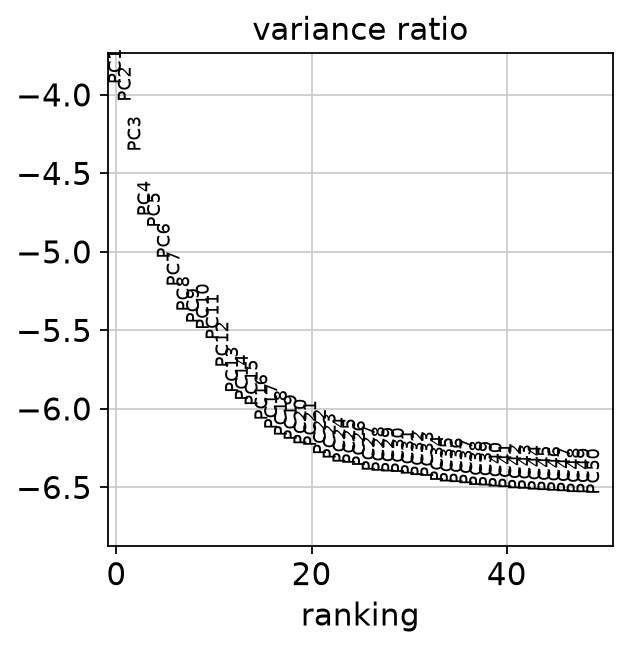

computing neighbors


    finished (0:00:52)


computing UMAP


    finished (0:00:14)


running Leiden clustering


...

running Leiden clustering


    finished (0:00:00)


running Leiden clustering


    finished (0:00:00)


leiden_res_0_5
0    5051
1     175
2    1563
3    1680
4    1470
5    1997
6    5977
7     174
8     117
Name: count, dtype: int64


In [6]:
n_hvg = int(adata.var["highly_variable"].sum())
n_comps = int(min(50, adata.n_obs - 1, max(2, n_hvg) - 1))
sc.tl.pca(
    adata,
    n_comps=n_comps,
    svd_solver="arpack",
    mask_var="highly_variable",
    random_state=0,
)

sc.pl.pca_variance_ratio(adata, n_pcs=n_comps, log=True, show=False)
save_and_show(FIG_DIR / "pca_variance_ratio.png", dpi=160, bbox_inches="tight")

sc.pp.neighbors(adata, n_neighbors=15, n_pcs=min(30, n_comps), use_rep="X_pca")
sc.tl.umap(adata, random_state=0)

for resolution in [0.2, 0.5, 1.0]:
    key = f"leiden_res_{str(resolution).replace('.', '_')}"
    sc.tl.leiden(
        adata,
        resolution=resolution,
        key_added=key,
        flavor="igraph",
        n_iterations=2,
        directed=False,
    )

CLUSTER_KEY = "leiden_res_0_5"
cluster_counts = adata.obs[CLUSTER_KEY].value_counts().sort_index()
cluster_counts.to_csv(TABLE_DIR / "cluster_counts_leiden_res_0_5.csv", header=["n_cells"])

sample_cluster = pd.crosstab(adata.obs["sample"].astype(str), adata.obs[CLUSTER_KEY].astype(str))
sample_cluster.to_csv(TABLE_DIR / "cluster_counts_by_sample.csv")
sample_cluster_pct = sample_cluster.div(sample_cluster.sum(axis=1), axis=0) * 100
sample_cluster_pct.to_csv(TABLE_DIR / "cluster_percent_by_sample.csv")

condition_cluster = pd.crosstab(adata.obs["condition"].astype(str), adata.obs[CLUSTER_KEY].astype(str))
condition_cluster.to_csv(TABLE_DIR / "cluster_counts_by_condition.csv")
condition_cluster_pct = condition_cluster.div(condition_cluster.sum(axis=1), axis=0) * 100
condition_cluster_pct.to_csv(TABLE_DIR / "cluster_percent_by_condition.csv")

print(cluster_counts)


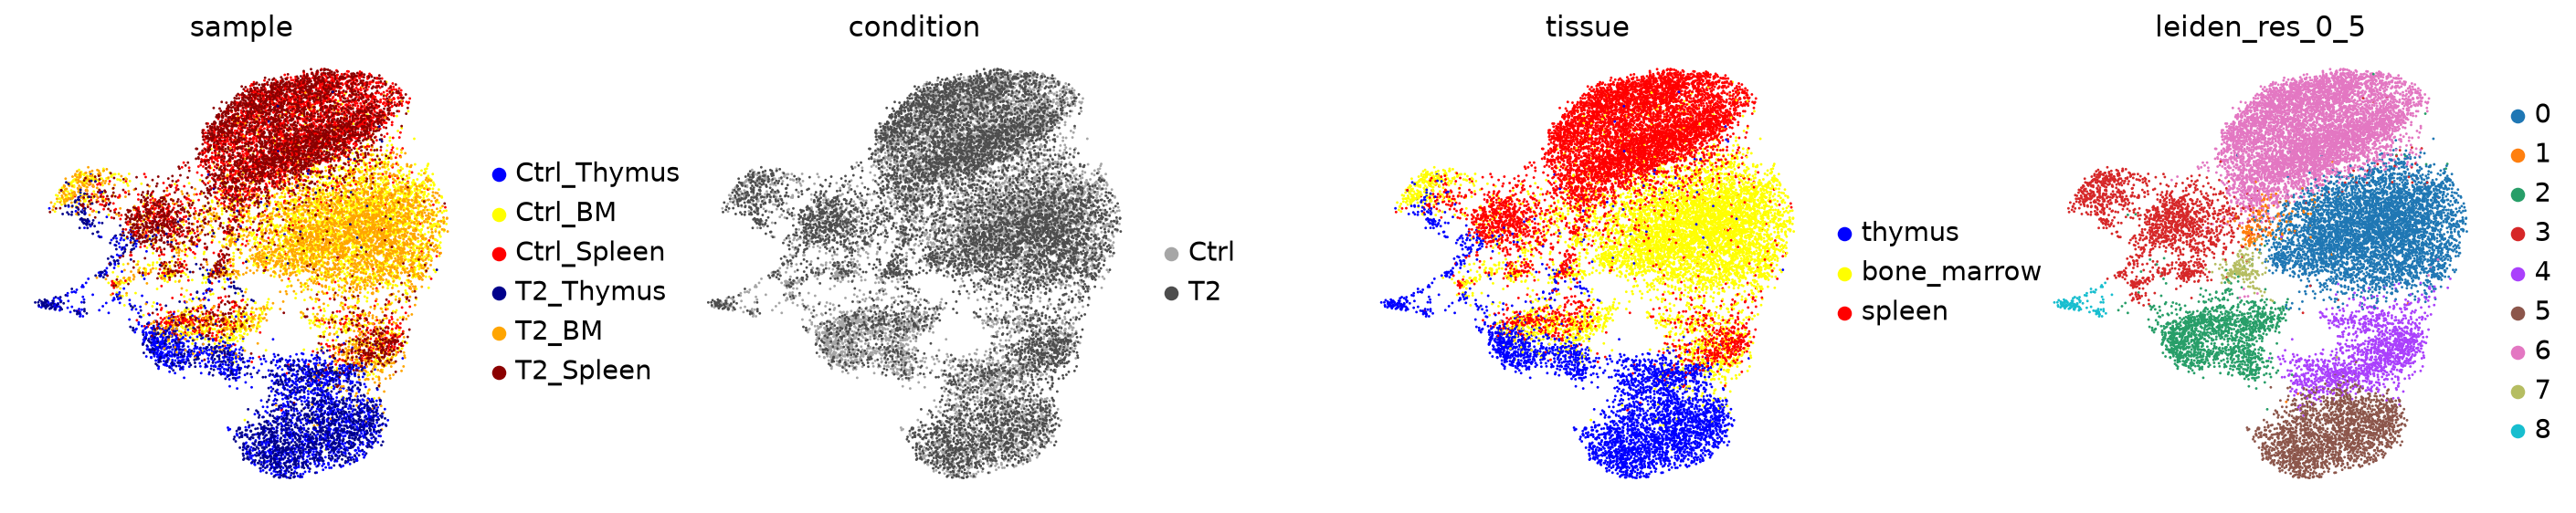

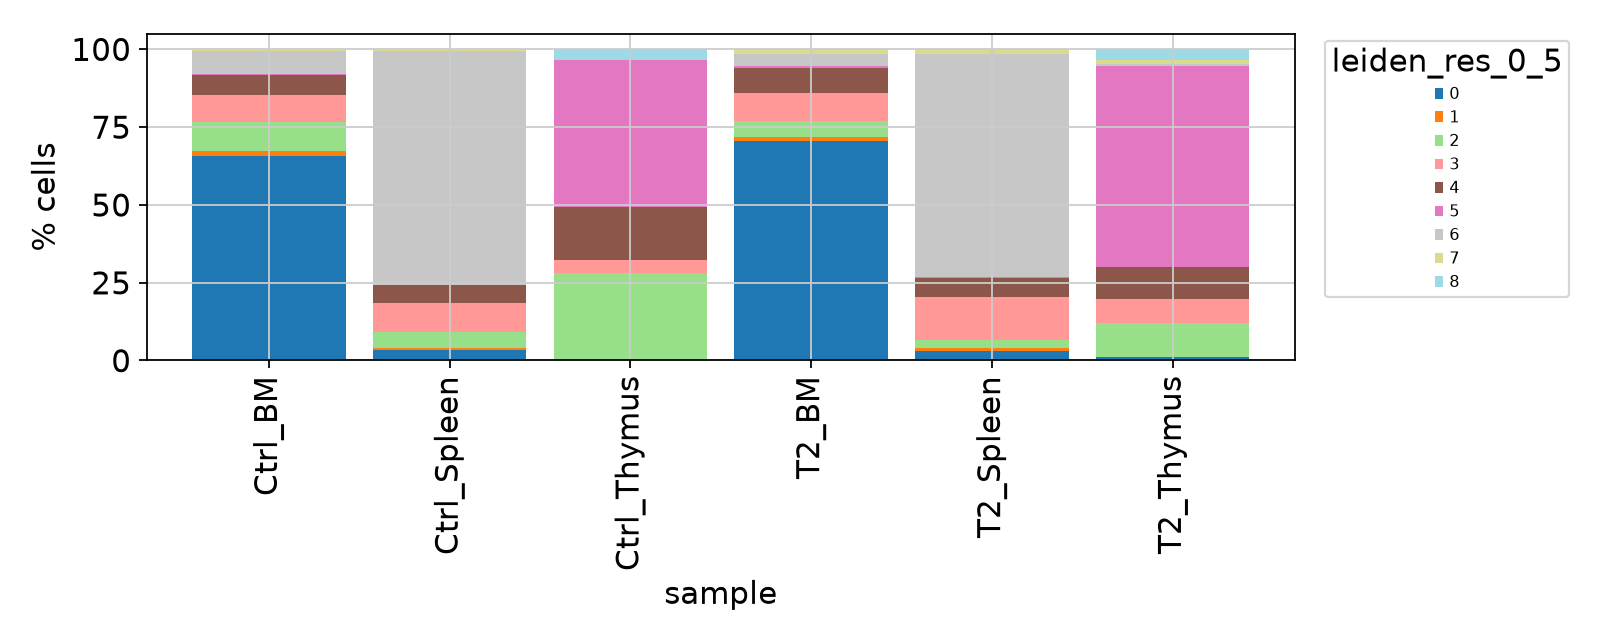

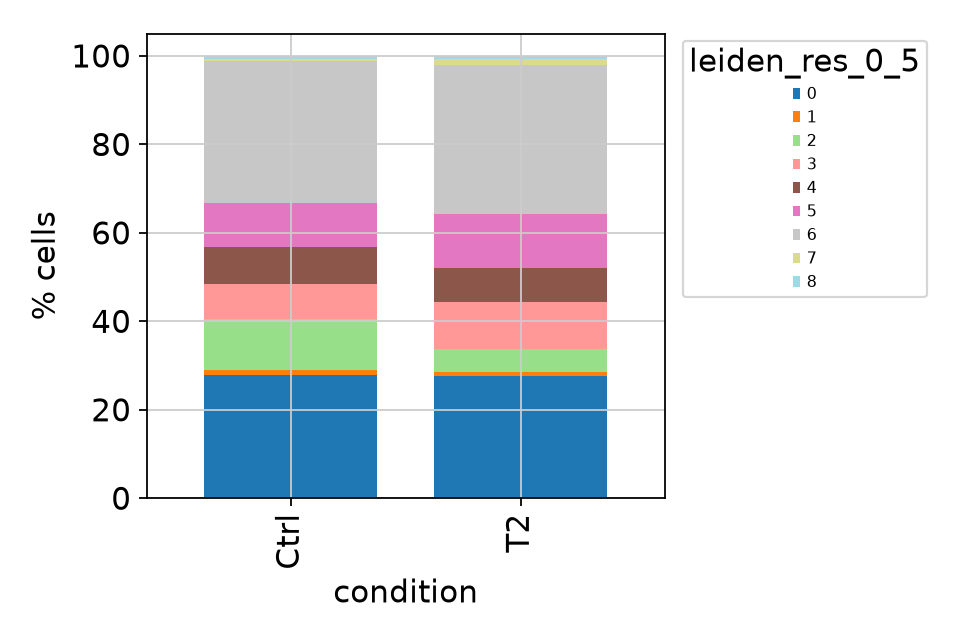

In [7]:
sc.pl.umap(
    adata,
    color=["sample", "condition", "tissue", CLUSTER_KEY],
    wspace=0.35,
    show=False,
)
save_and_show(FIG_DIR / "umap_sample_condition_tissue_cluster.png", dpi=160, bbox_inches="tight")

ax = sample_cluster_pct.plot(kind="bar", stacked=True, figsize=(10, 4), width=0.85, colormap="tab20")
ax.set_ylabel("% cells")
ax.set_xlabel("sample")
ax.legend(title=CLUSTER_KEY, bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)
plt.tight_layout()
save_and_show(FIG_DIR / "cluster_percent_by_sample.png", dpi=160, bbox_inches=None)

ax = condition_cluster_pct.plot(kind="bar", stacked=True, figsize=(6, 4), width=0.75, colormap="tab20")
ax.set_ylabel("% cells")
ax.set_xlabel("condition")
ax.legend(title=CLUSTER_KEY, bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)
plt.tight_layout()
save_and_show(FIG_DIR / "cluster_percent_by_condition.png", dpi=160, bbox_inches=None)


## Marker plots and marker ranking

Marker sets are adapted for mouse iNKT/NK-like biology and filtered to genes present in the dataset.


In [8]:
candidate_marker_genes = {
    "iNKT/T lineage": ["Trac", "Trav11", "Traj18", "Cd3d", "Cd3e", "Zbtb16"],
    "NK/cytotoxic": ["Klrb1c", "Nkg7", "Prf1", "Gzma", "Gzmb", "Ifng"],
    "Maturation": ["Cd27", "Itgam", "Il2rb", "Klrg1", "Tbx21", "Eomes"],
    "Migration/activation": ["Cxcr6", "S1pr1", "Sell", "Ccr7", "Il7r"],
}

present = {gene.upper(): gene for gene in adata.var_names.astype(str)}
marker_genes = {
    group: [present[gene.upper()] for gene in genes if gene.upper() in present]
    for group, genes in candidate_marker_genes.items()
}
marker_genes = {group: genes for group, genes in marker_genes.items() if genes}
flat_markers = [gene for genes in marker_genes.values() for gene in genes]

(TABLE_DIR / "marker_genes_used.json").write_text(json.dumps(marker_genes, indent=2, sort_keys=True, allow_nan=False) + "\n")
print(marker_genes)


{'iNKT/T lineage': ['Trac', 'Trav11', 'Traj18', 'Cd3d', 'Cd3e', 'Zbtb16'], 'NK/cytotoxic': ['Klrb1c', 'Nkg7', 'Prf1', 'Gzma', 'Gzmb', 'Ifng'], 'Maturation': ['Cd27', 'Itgam', 'Il2rb', 'Klrg1', 'Tbx21', 'Eomes'], 'Migration/activation': ['Cxcr6', 'S1pr1', 'Sell', 'Ccr7', 'Il7r']}


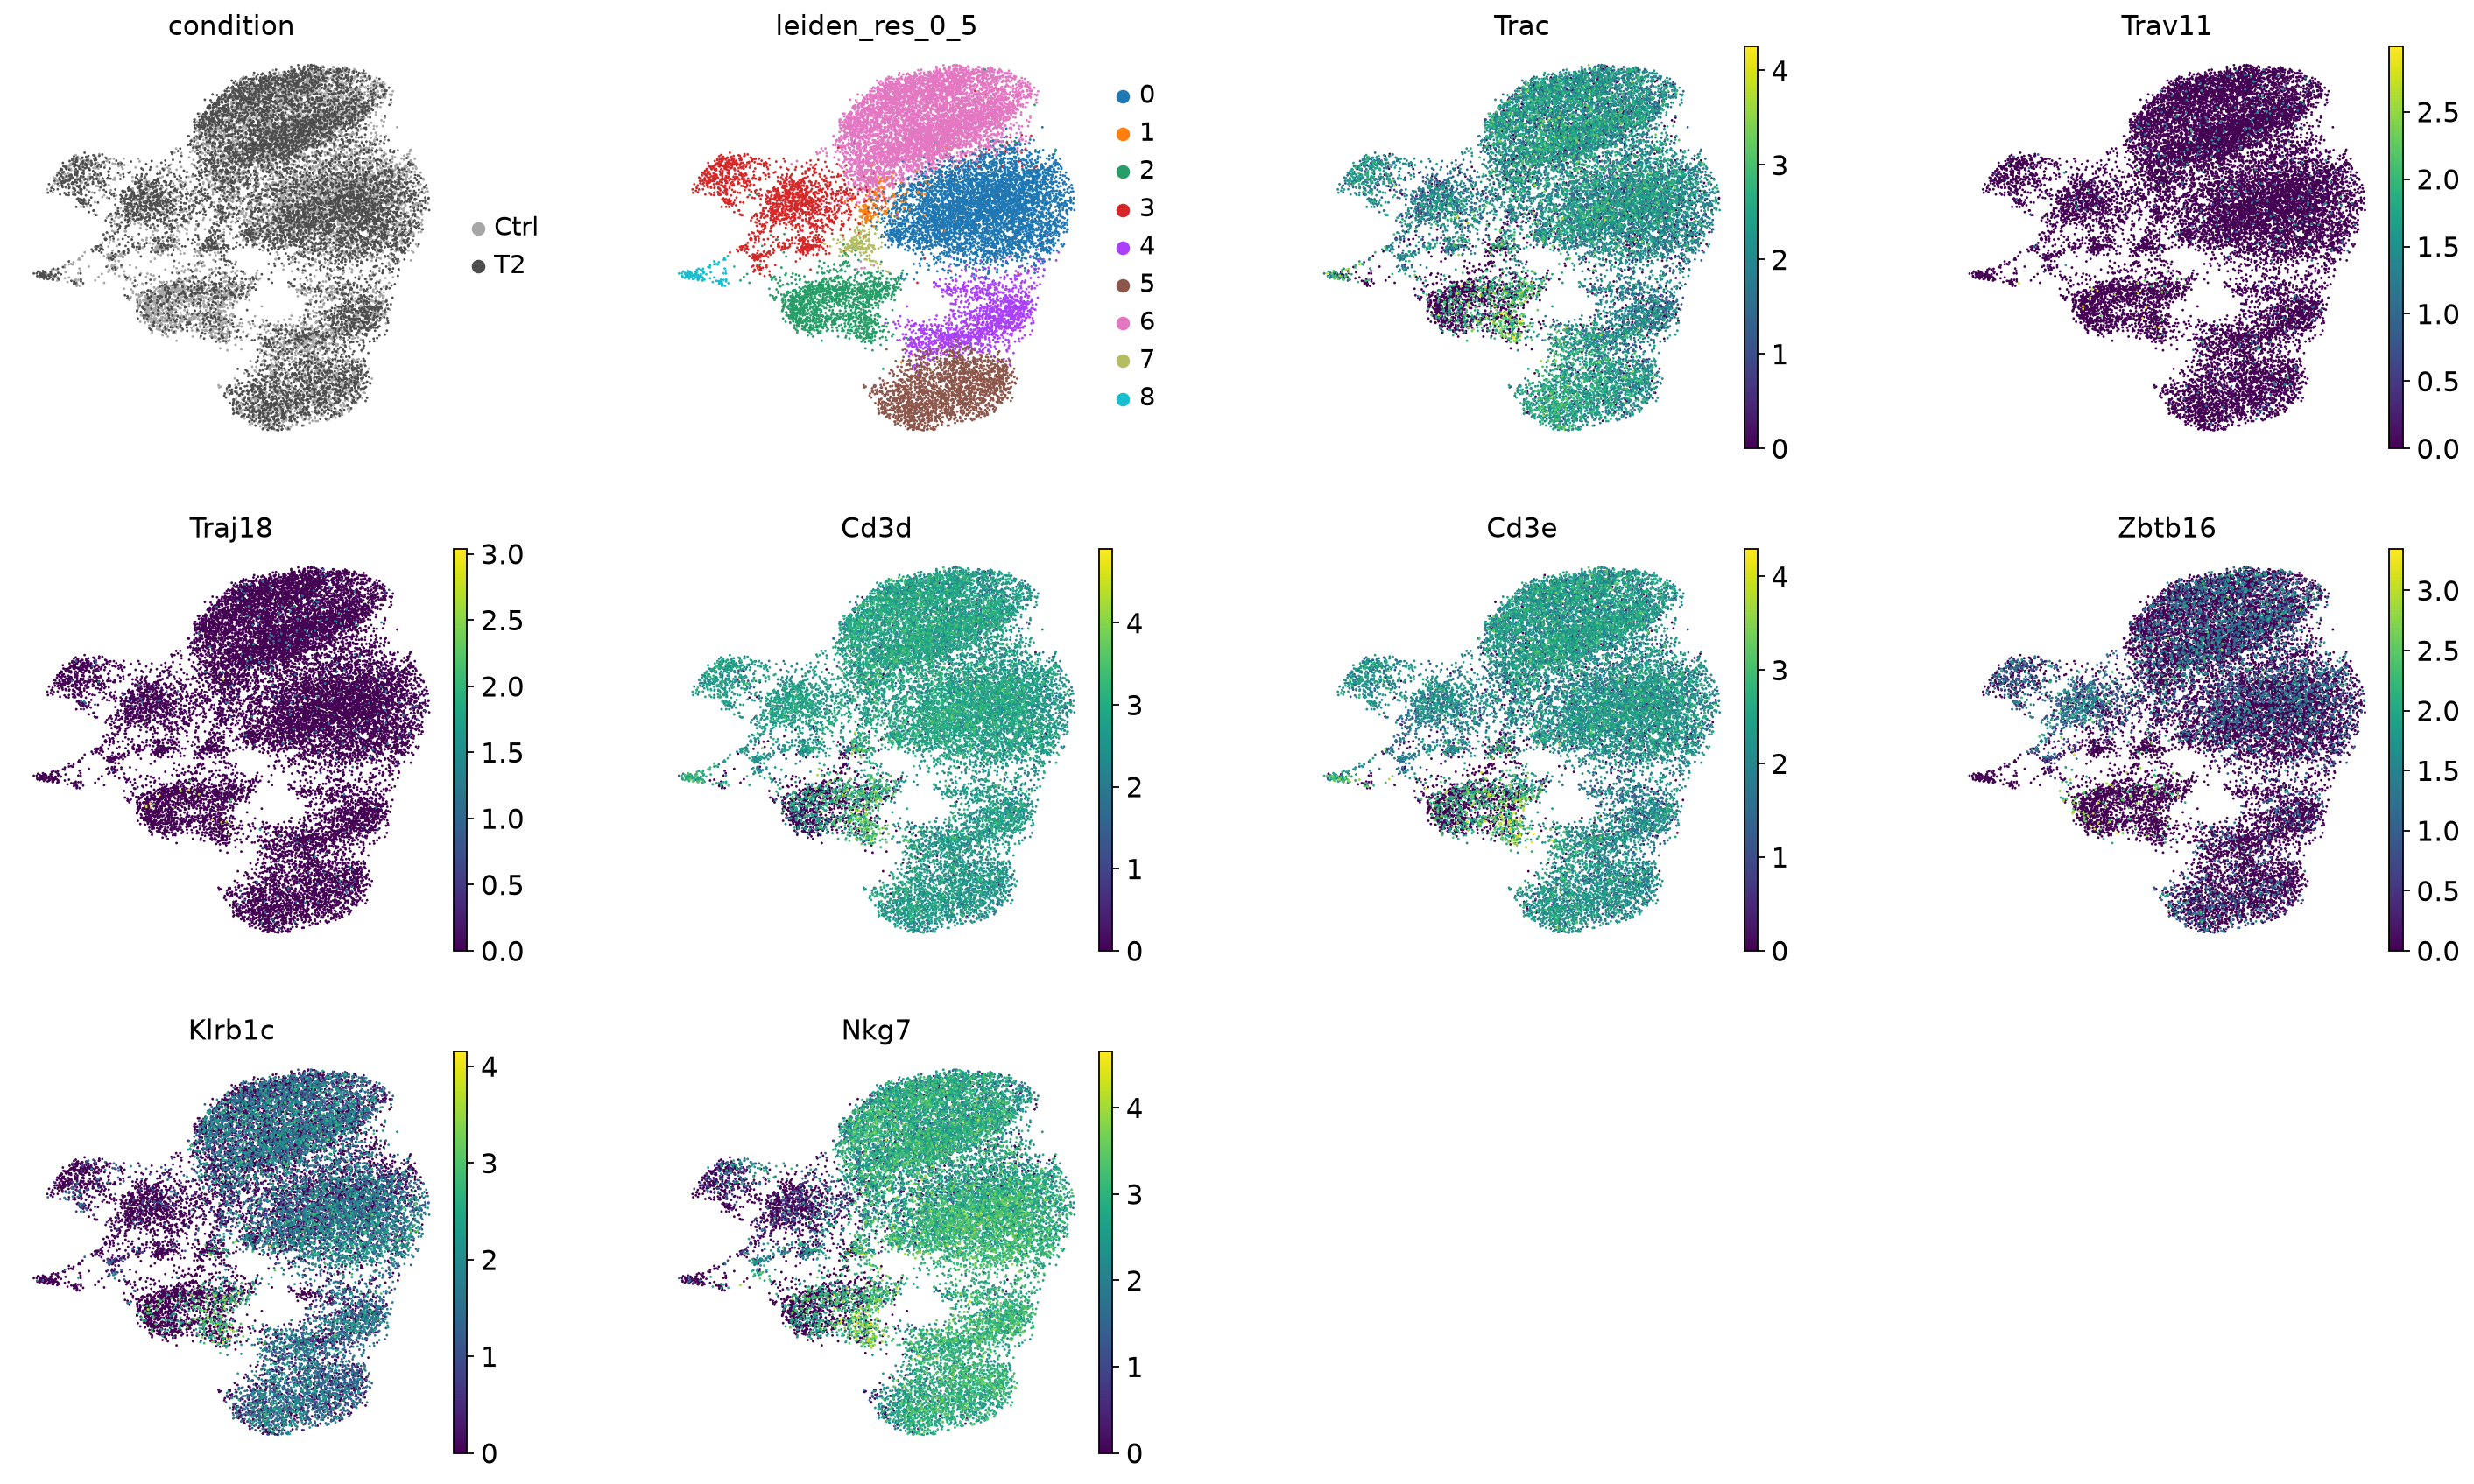

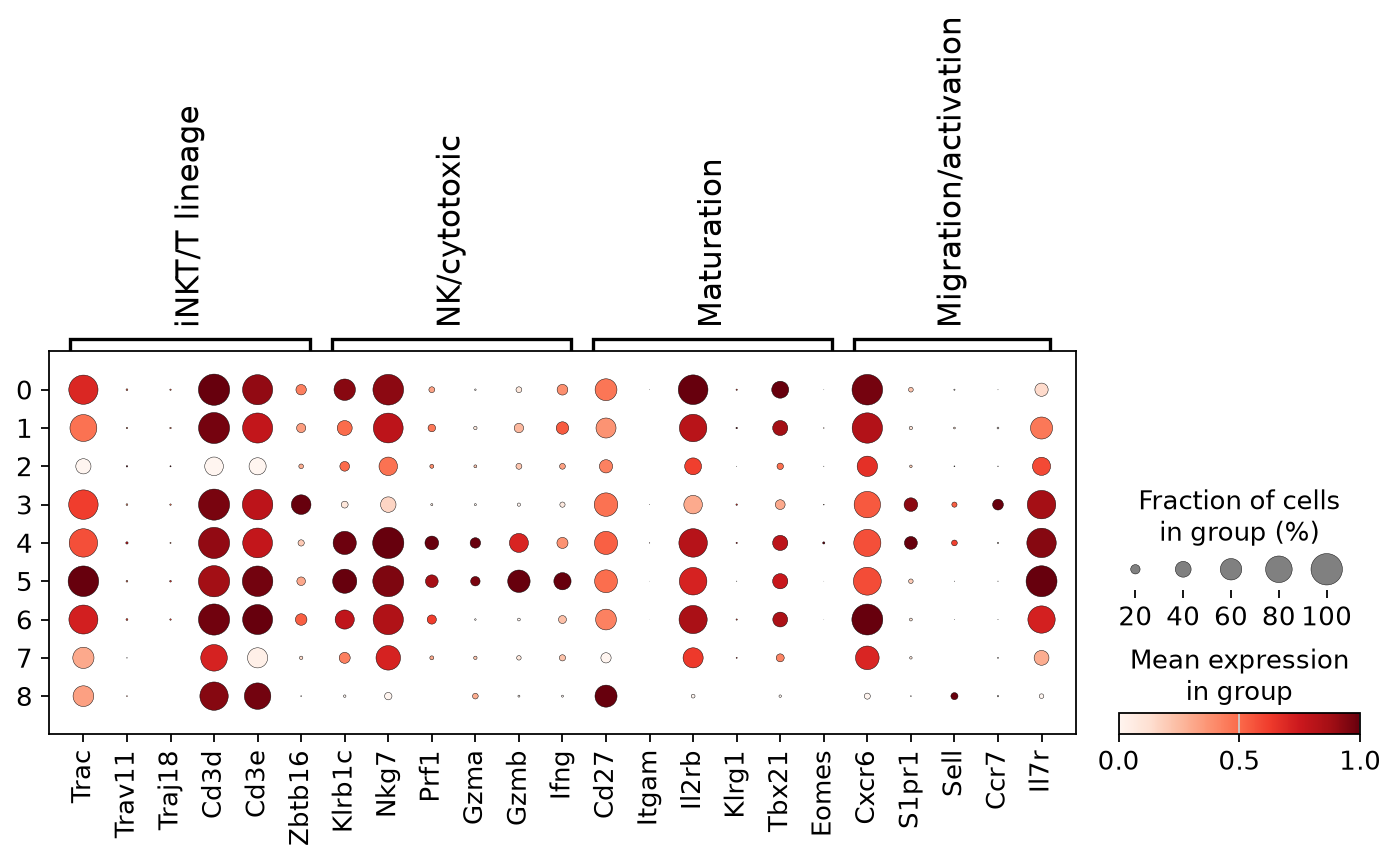

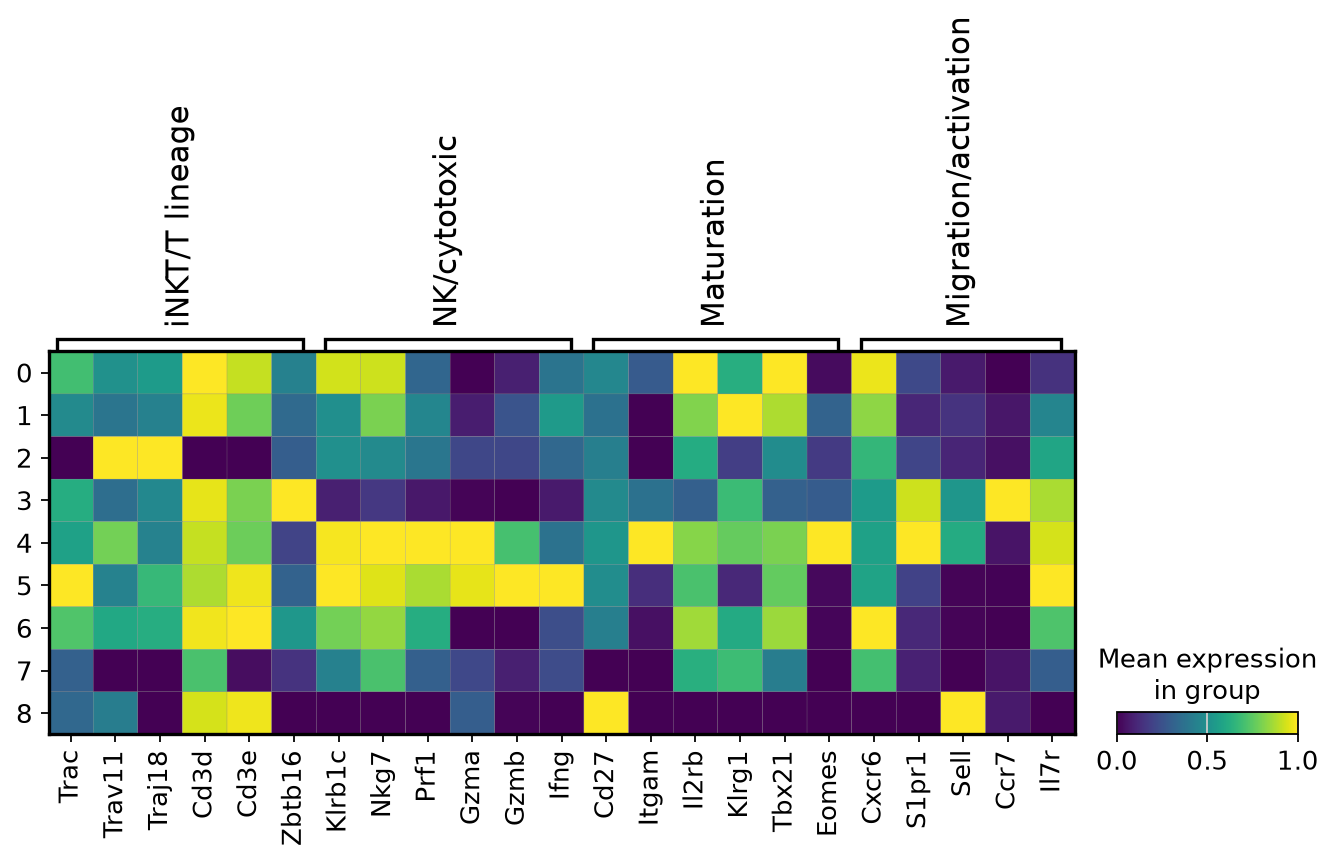

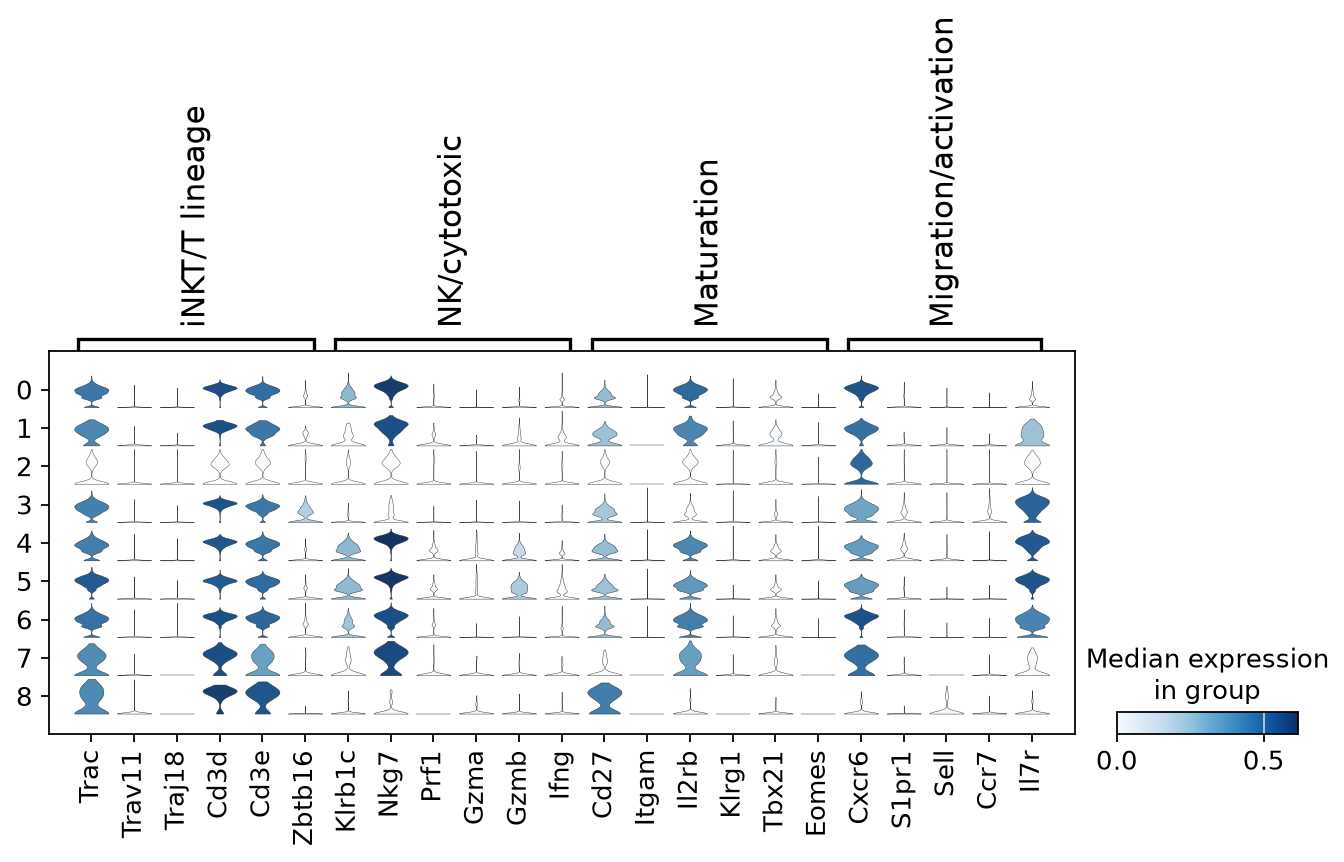

In [9]:
if flat_markers:
    sc.pl.umap(
        adata,
        color=["condition", CLUSTER_KEY] + flat_markers[:8],
        ncols=4,
        wspace=0.35,
        show=False,
    )
    save_and_show(FIG_DIR / "umap_condition_cluster_top_markers.png", dpi=160, bbox_inches="tight")

    sc.pl.dotplot(adata, marker_genes, groupby=CLUSTER_KEY, standard_scale="var", show=False)
    save_and_show(FIG_DIR / "dotplot_inkt_markers_by_cluster.png", dpi=160, bbox_inches="tight")

    sc.pl.matrixplot(adata, marker_genes, groupby=CLUSTER_KEY, standard_scale="var", show=False)
    save_and_show(FIG_DIR / "matrixplot_inkt_markers_by_cluster.png", dpi=160, bbox_inches="tight")

    sc.pl.stacked_violin(adata, marker_genes, groupby=CLUSTER_KEY, standard_scale="var", show=False)
    save_and_show(FIG_DIR / "stacked_violin_inkt_markers_by_cluster.png", dpi=160, bbox_inches="tight")


ranking genes


    finished (0:00:01)


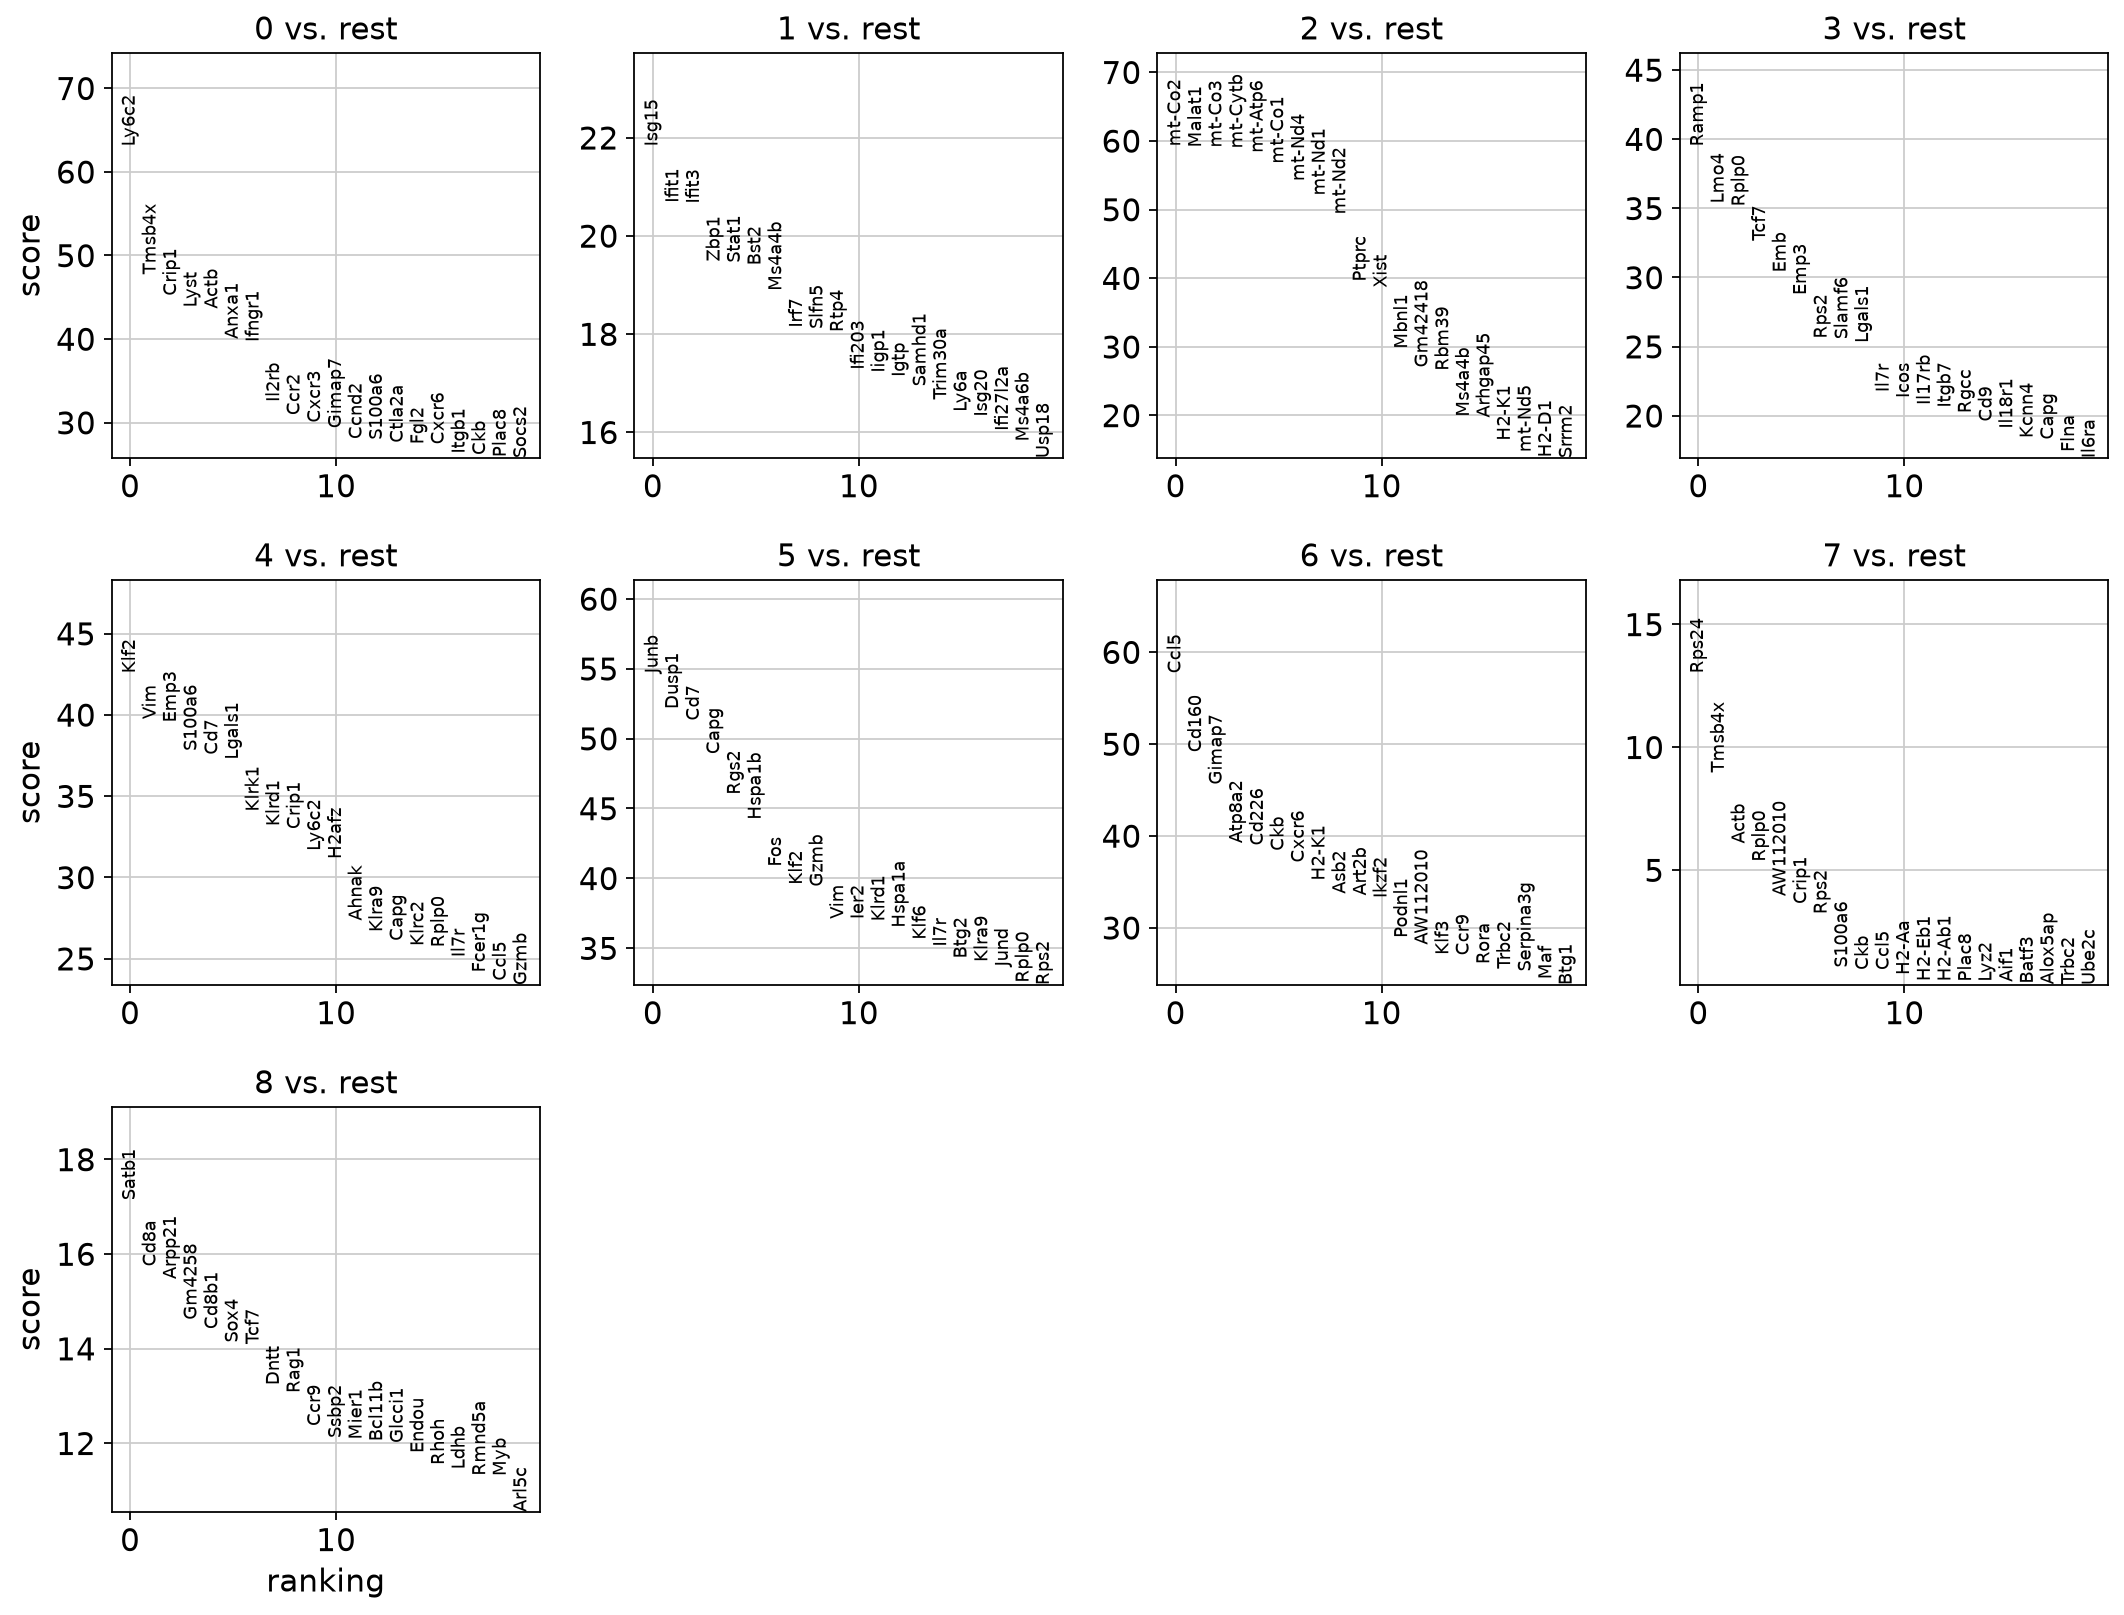

ranking genes


    finished (0:00:01)


  group   names     scores  logfoldchanges  pvals  pvals_adj
0     0   Ly6c2  63.056698        2.790210    0.0        0.0
1     0  Tmsb4x  47.750965        0.519231    0.0        0.0
2     0   Crip1  45.188091        1.453708    0.0        0.0
3     0    Lyst  43.789856        1.522588    0.0        0.0
4     0    Actb  43.632908        0.638888    0.0        0.0
    names     scores  logfoldchanges          pvals      pvals_adj
0   Rps24  23.594055        0.219503  4.435541e-123  1.330662e-119
1    Actb  20.271444        0.297577   2.298108e-91   3.447162e-88
2  mt-Nd3  19.815012        0.701962   2.209559e-87   2.209559e-84
3  Tmsb4x  19.212971        0.190595   2.882830e-82   2.162122e-79
4     Jun  18.091774        0.687836   3.699834e-73   2.219900e-70


In [10]:
sc.tl.rank_genes_groups(
    adata,
    groupby=CLUSTER_KEY,
    method="wilcoxon",
    mask_var="highly_variable",
    key_added="rank_genes_leiden_res_0_5",
)
rank_df = sc.get.rank_genes_groups_df(
    adata,
    group=None,
    key="rank_genes_leiden_res_0_5",
)
rank_df.groupby("group", observed=True).head(100).to_csv(
    TABLE_DIR / "rank_genes_groups_leiden_res_0_5_top100.csv",
    index=False,
)

sc.pl.rank_genes_groups(
    adata,
    key="rank_genes_leiden_res_0_5",
    n_genes=20,
    sharey=False,
    show=False,
)
save_and_show(FIG_DIR / "rank_genes_groups_by_cluster.png", dpi=160, bbox_inches="tight")

sc.tl.rank_genes_groups(
    adata,
    groupby="condition",
    groups=["T2"],
    reference="Ctrl",
    method="wilcoxon",
    mask_var="highly_variable",
    key_added="rank_genes_condition_t2_vs_ctrl",
)
condition_rank_df = sc.get.rank_genes_groups_df(
    adata,
    group="T2",
    key="rank_genes_condition_t2_vs_ctrl",
)
condition_rank_df.head(500).to_csv(TABLE_DIR / "rank_genes_condition_t2_vs_ctrl_top500.csv", index=False)

print(rank_df.head())
print(condition_rank_df.head())


## PAGA, diffusion map, and DPT pseudotime


running PAGA


    finished (0:00:00)


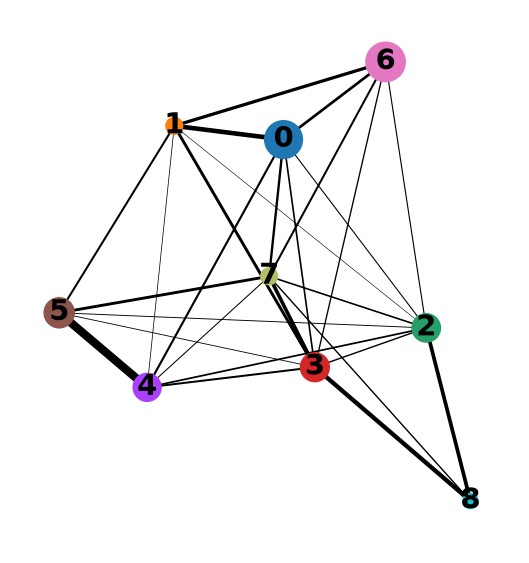

computing Diffusion Maps using n_comps=15(=n_dcs)


computing transitions


    finished (0:00:00)


    eigenvalues of transition matrix
    [1.         0.98571426 0.98219246 0.97429985 0.96291846 0.9558627
     0.94901204 0.94505167 0.93881494 0.93742037 0.9345626  0.9152901
     0.9095764  0.90264714 0.90031147]


    finished (0:00:00)


computing Diffusion Pseudotime using n_dcs=10


    finished (0:00:00)


DPT root cluster: 8


In [11]:
sc.tl.paga(adata, groups=CLUSTER_KEY)
sc.pl.paga(adata, color=CLUSTER_KEY, threshold=0.03, show=False)
save_and_show(FIG_DIR / "trajectory_paga_cluster_graph.png", dpi=160, bbox_inches="tight")

sc.tl.diffmap(adata)

root_marker_candidates = ["Cd27", "Itgam", "Il2rb", "Klrb1c", "Tcrb", "Zbtb16"]
root_markers = [present[g.upper()] for g in root_marker_candidates if g.upper() in present]
root_scores = []
if root_markers:
    marker_df = sc.get.obs_df(adata, keys=root_markers, use_raw=True)
    marker_df[CLUSTER_KEY] = adata.obs[CLUSTER_KEY].astype(str).to_numpy()
    cluster_marker_means = marker_df.groupby(CLUSTER_KEY, observed=True)[root_markers].mean()
    if "Cd27" in cluster_marker_means.columns and "Itgam" in cluster_marker_means.columns:
        root_score = cluster_marker_means["Cd27"] - cluster_marker_means["Itgam"]
    elif "Cd27" in cluster_marker_means.columns:
        root_score = cluster_marker_means["Cd27"]
    else:
        root_score = cluster_marker_means.mean(axis=1)
    root_cluster = str(root_score.sort_values(ascending=False).index[0])
    root_scores = (
        cluster_marker_means.assign(root_score=root_score)
        .reset_index()
        .sort_values("root_score", ascending=False)
        .to_dict(orient="records")
    )
else:
    root_cluster = str(sorted(adata.obs[CLUSTER_KEY].astype(str).unique())[0])

root_cells = np.flatnonzero(adata.obs[CLUSTER_KEY].astype(str).to_numpy() == root_cluster)
if len(root_cells) == 0:
    raise RuntimeError(f"No cells found for DPT root cluster {root_cluster}")
adata.uns["iroot"] = int(root_cells[0])

sc.tl.dpt(adata, n_dcs=min(10, adata.obsm["X_diffmap"].shape[1]))

pd.DataFrame(root_scores).to_csv(TABLE_DIR / "trajectory_root_marker_scores.csv", index=False)
(TABLE_DIR / "trajectory_root_summary.json").write_text(
    json.dumps(
        {
            "cluster_key": CLUSTER_KEY,
            "root_cluster": root_cluster,
            "root_cell": str(adata.obs_names[adata.uns["iroot"]]),
            "root_markers_available": root_markers,
        },
        indent=2,
        sort_keys=True,
        allow_nan=False,
    )
    + "\n"
)

print("DPT root cluster:", root_cluster)


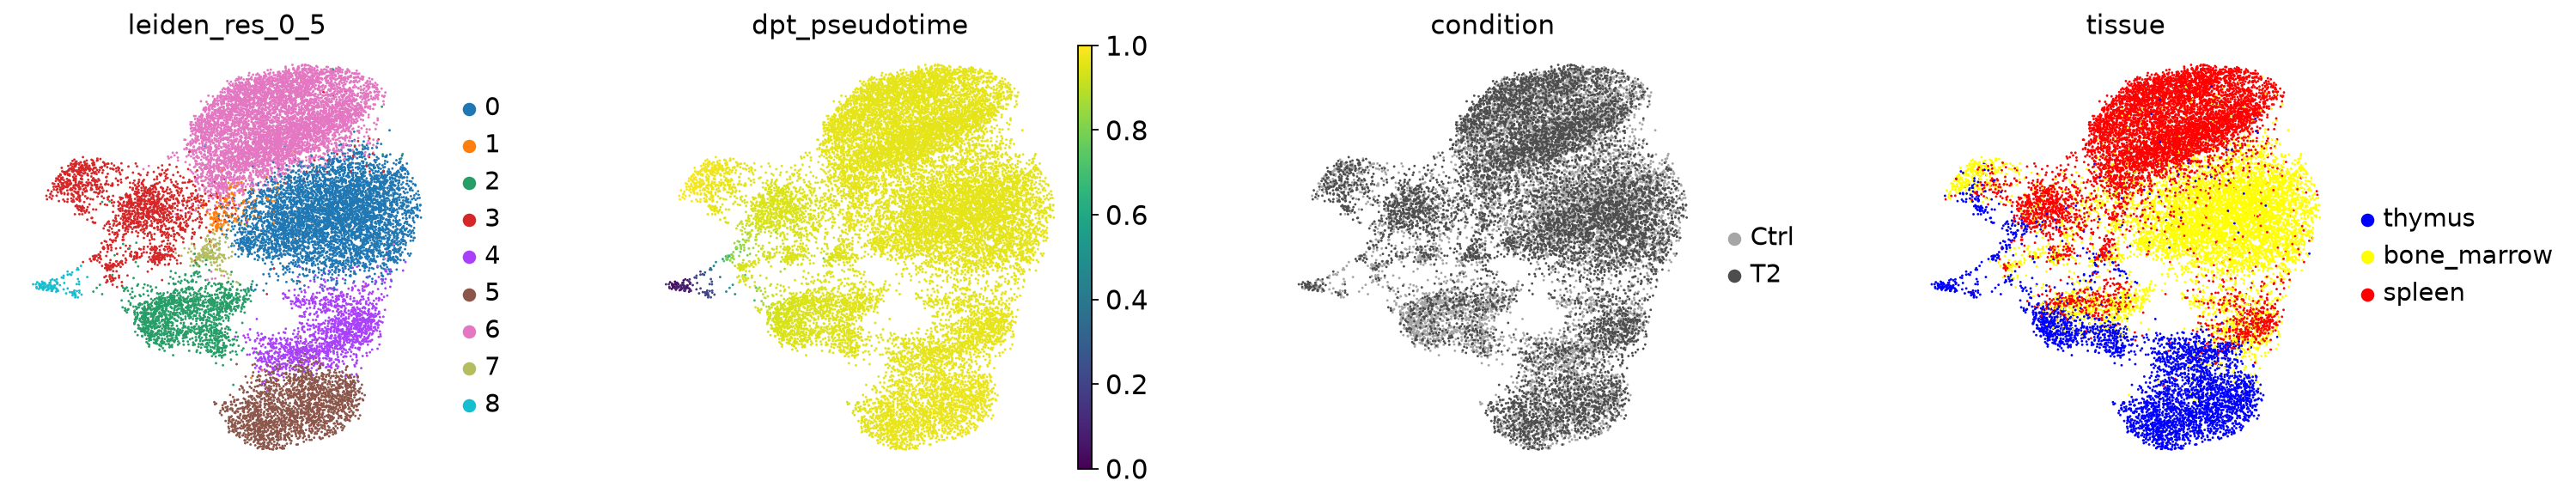

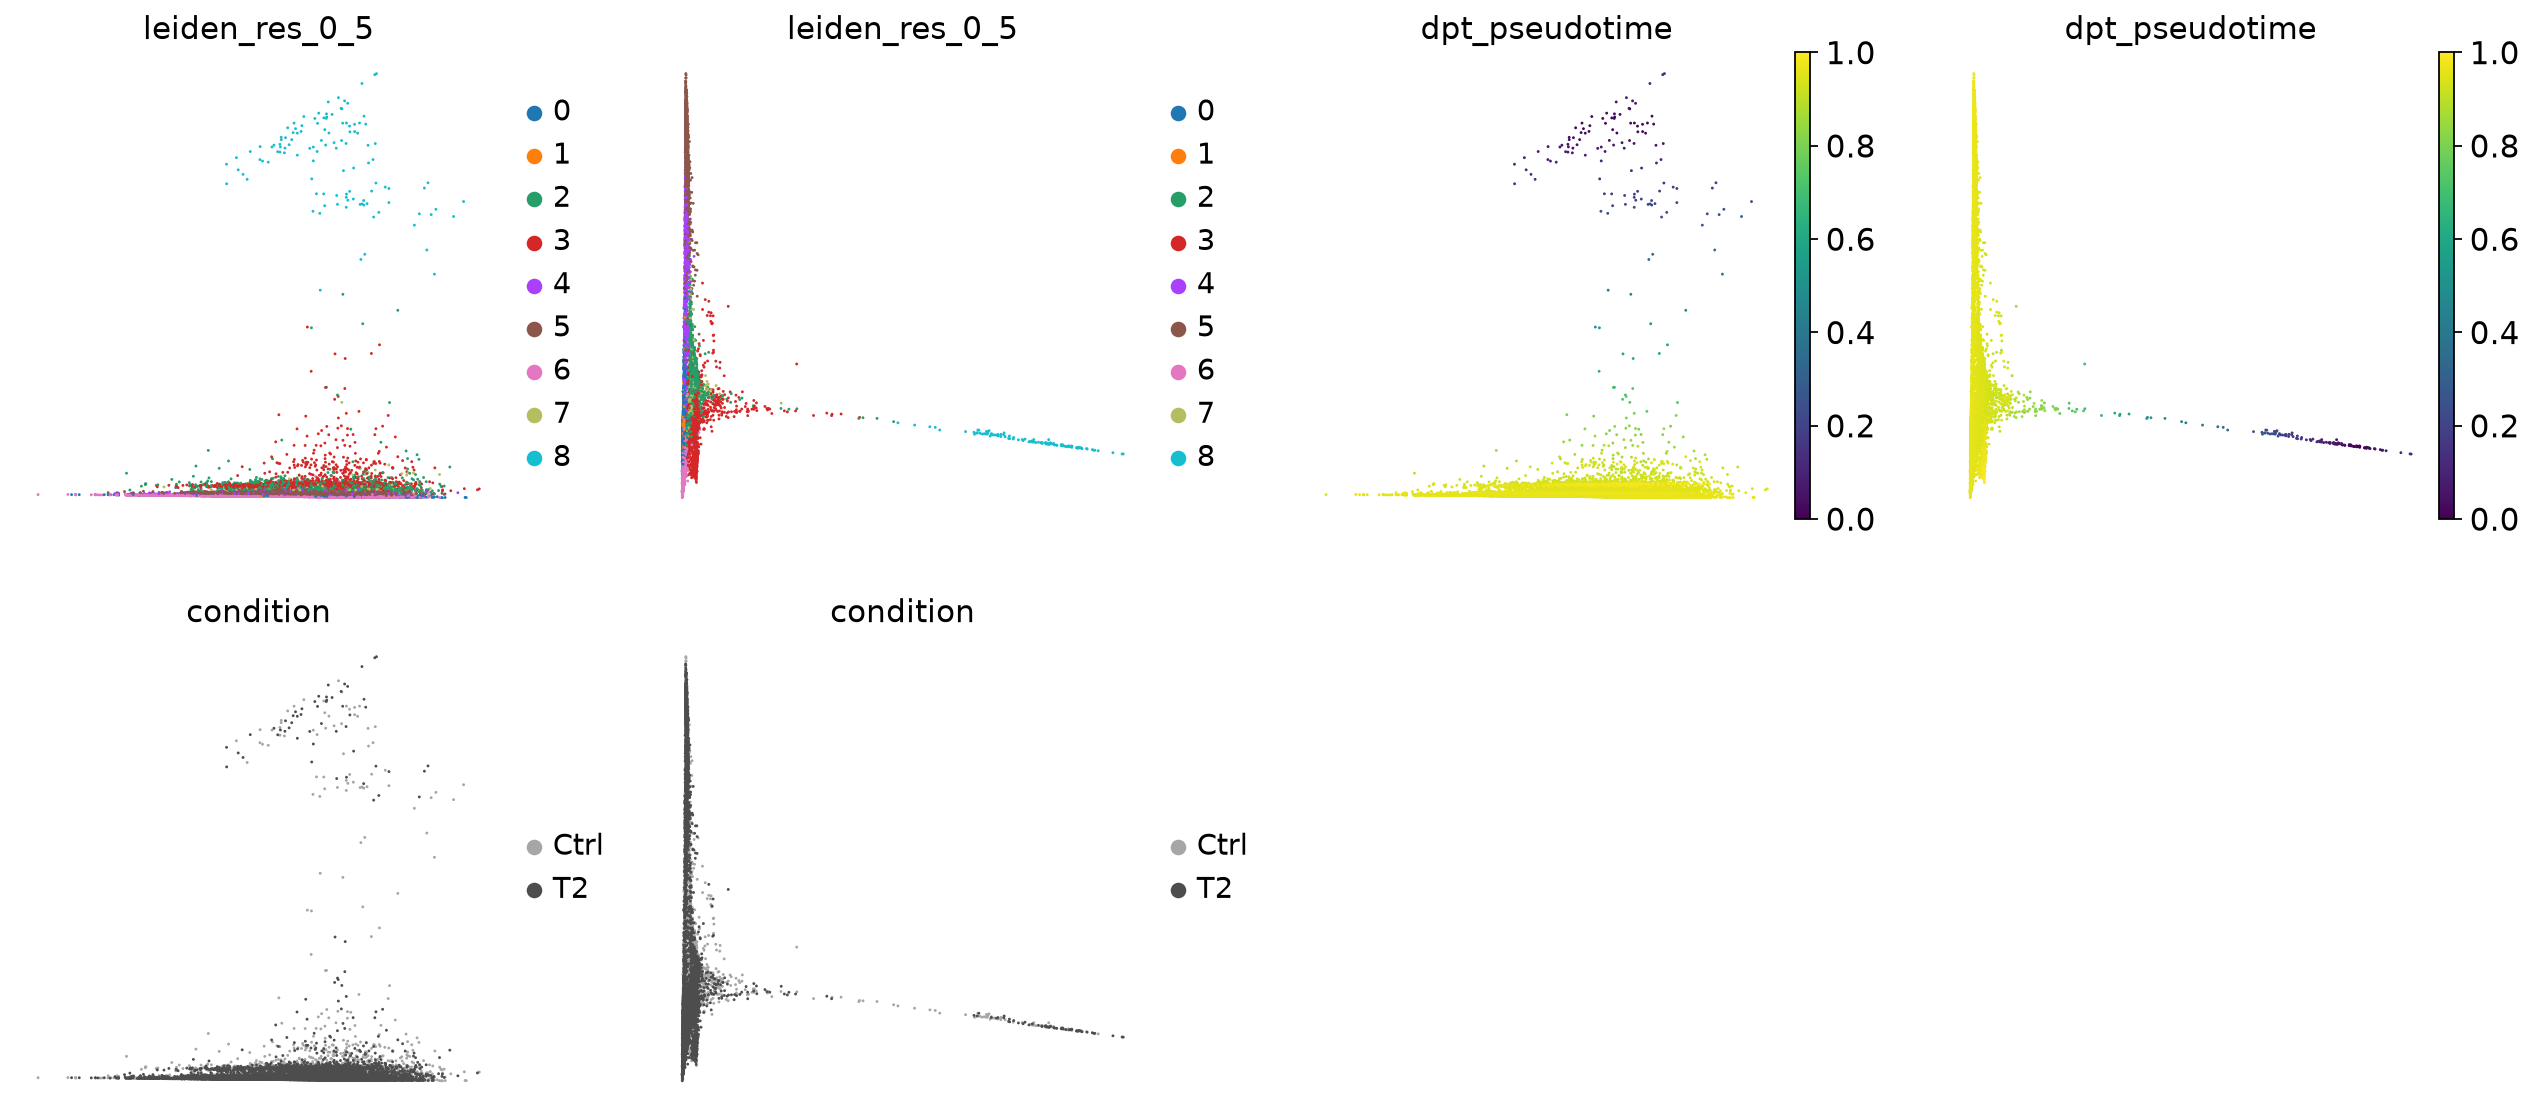

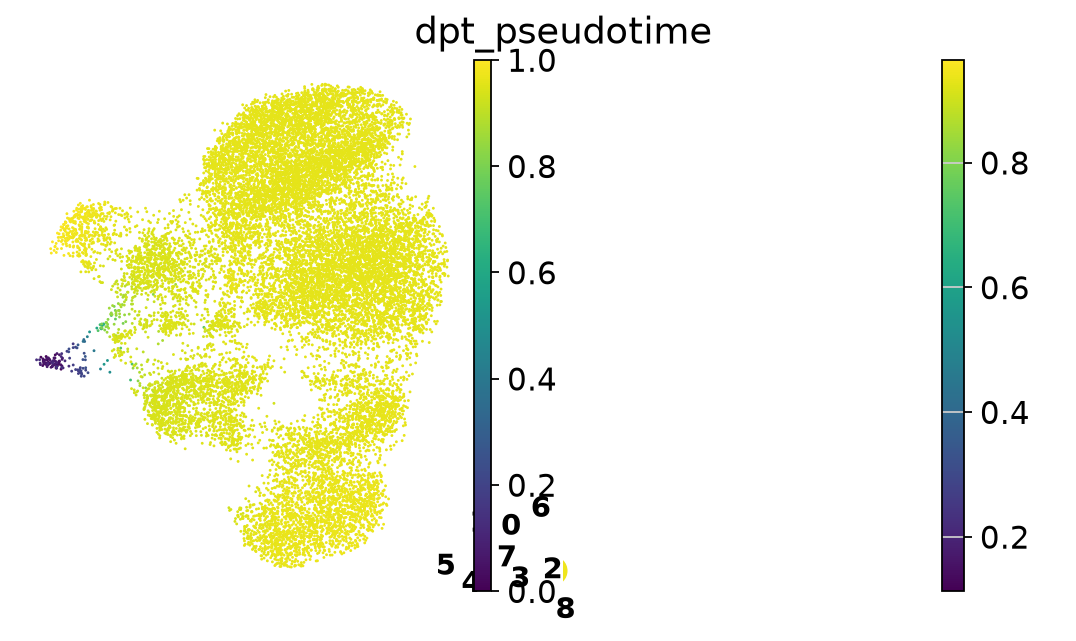

                 count      mean       std       min       25%       50%  \
leiden_res_0_5                                                             
0               5051.0  0.958195  0.001534  0.943054  0.957415  0.958370   
1                175.0  0.960767  0.003109  0.950882  0.959013  0.960508   
2               1563.0  0.942121  0.027169  0.445798  0.940430  0.945116   
3               1680.0  0.944860  0.033844  0.530396  0.941102  0.945356   
4               1470.0  0.959931  0.003156  0.931690  0.958171  0.960259   

                     75%       max  
leiden_res_0_5                      
0               0.959182  0.962381  
1               0.963234  0.966837  
2               0.950018  0.957492  
3               0.955363  1.000000  
4               0.962134  0.969026  
                        count      mean       std       min       25%  \
condition tissue                                                        
Ctrl      thymus       2033.0  0.928607  0.143970  0.010450  0

In [12]:
sc.pl.umap(adata, color=[CLUSTER_KEY, "dpt_pseudotime", "condition", "tissue"], wspace=0.35, show=False)
save_and_show(FIG_DIR / "trajectory_umap_dpt_pseudotime.png", dpi=160, bbox_inches="tight")

sc.pl.diffmap(
    adata,
    color=[CLUSTER_KEY, "dpt_pseudotime", "condition"],
    components=["1,2", "2,3"],
    show=False,
)
save_and_show(FIG_DIR / "trajectory_diffmap_dpt_pseudotime.png", dpi=160, bbox_inches="tight")

sc.pl.paga_compare(adata, basis="umap", color="dpt_pseudotime", threshold=0.03, show=False)
save_and_show(FIG_DIR / "trajectory_paga_compare_umap_pseudotime.png", dpi=160, bbox_inches="tight")

pseudotime_by_cluster = adata.obs.groupby(CLUSTER_KEY, observed=True)["dpt_pseudotime"].describe()
pseudotime_by_sample = adata.obs.groupby("sample", observed=True)["dpt_pseudotime"].describe()
pseudotime_by_condition_tissue = adata.obs.groupby(["condition", "tissue"], observed=True)["dpt_pseudotime"].describe()
pseudotime_by_cluster.to_csv(TABLE_DIR / "trajectory_pseudotime_by_cluster.csv")
pseudotime_by_sample.to_csv(TABLE_DIR / "trajectory_pseudotime_by_sample.csv")
pseudotime_by_condition_tissue.to_csv(TABLE_DIR / "trajectory_pseudotime_by_condition_tissue.csv")

if flat_markers:
    marker_pt = []
    pt = adata.obs["dpt_pseudotime"].to_numpy()
    for gene in flat_markers:
        values = sc.get.obs_df(adata, keys=[gene], use_raw=True)[gene].to_numpy()
        mask = np.isfinite(pt) & np.isfinite(values)
        if mask.sum() >= 10:
            rho, pvalue = spearmanr(values[mask], pt[mask])
            marker_pt.append({"gene": gene, "spearman_rho_vs_dpt": float(rho), "pvalue": float(pvalue)})
    pd.DataFrame(marker_pt).sort_values("spearman_rho_vs_dpt").to_csv(
        TABLE_DIR / "trajectory_marker_spearman_vs_dpt.csv",
        index=False,
    )

print(pseudotime_by_cluster.head())
print(pseudotime_by_condition_tissue)


## Save processed object and run summary


In [13]:
adata.write(PROCESSED_H5AD, compression="gzip")

summary = {
    "notebook": "scanpy_iNKT_preprocess_plotting_trajectory",
    "source_archive": "input.zip",
    "input_root": str(INPUT_ROOT.relative_to(ROOT)),
    "run_dir": str(RUN_DIR.relative_to(ROOT)),
    "processed_h5ad": str(PROCESSED_H5AD.relative_to(ROOT)),
    "shape": [int(adata.n_obs), int(adata.n_vars)],
    "counts_layer_available": "counts" in adata.layers,
    "cluster_key": CLUSTER_KEY,
    "n_clusters": int(adata.obs[CLUSTER_KEY].nunique()),
    "sample_counts": adata.obs["sample"].astype(str).value_counts().sort_index().to_dict(),
    "condition_counts": adata.obs["condition"].astype(str).value_counts().sort_index().to_dict(),
    "tissue_counts": adata.obs["tissue"].astype(str).value_counts().sort_index().to_dict(),
    "palettes": palette_state(adata),
    "dpt_root_cluster": root_cluster,
    "marker_genes_used": marker_genes,
    "figures": sorted(path.name for path in FIG_DIR.glob("*.png")),
    "tables": sorted(path.name for path in TABLE_DIR.glob("*")),
    "tutorial_sources": [
        "https://scanpy.scverse.org/en/stable/tutorials/index.html",
        "https://scanpy.scverse.org/en/stable/tutorials/basics/clustering.html",
        "https://scanpy.scverse.org/en/stable/tutorials/plotting/core.html",
        "https://scanpy.scverse.org/en/stable/tutorials/trajectories/paga-paul15.html",
    ],
    "skipped_steps": [
        "scVI integration: deferred to a separate CPU-heavy stage",
    ],
}

(RUN_DIR / "summary.json").write_text(json.dumps(summary, indent=2, sort_keys=True, allow_nan=False) + "\n")
print(json.dumps(summary, indent=2)[:5000])
summary


{
  "notebook": "scanpy_iNKT_preprocess_plotting_trajectory",
  "source_archive": "input.zip",
  "input_root": "input/iNKT/data",
  "run_dir": "output/iNKT_scanpy_tutorial_run",
  "processed_h5ad": "output/iNKT_scanpy_tutorial_run/inkt_scanpy_tutorial_processed.h5ad",
  "shape": [
    18204,
    15741
  ],
  "counts_layer_available": true,
  "cluster_key": "leiden_res_0_5",
  "n_clusters": 9,
  "sample_counts": {
    "Ctrl_BM": 3978,
    "Ctrl_Spleen": 3808,
    "Ctrl_Thymus": 2033,
    "T2_BM": 3095,
    "T2_Spleen": 3737,
    "T2_Thymus": 1553
  },
  "condition_counts": {
    "Ctrl": 9819,
    "T2": 8385
  },
  "tissue_counts": {
    "bone_marrow": 7073,
    "spleen": 7545,
    "thymus": 3586
  },
  "palettes": {
    "sample": {
      "categories": [
        "Ctrl_Thymus",
        "Ctrl_BM",
        "Ctrl_Spleen",
        "T2_Thymus",
        "T2_BM",
        "T2_Spleen"
      ],
      "colors": [
        "#0000FF",
        "#FFFF00",
        "#FF0000",
        "#00008B",
        "#F

{'notebook': 'scanpy_iNKT_preprocess_plotting_trajectory',
 'source_archive': 'input.zip',
 'input_root': 'input/iNKT/data',
 'run_dir': 'output/iNKT_scanpy_tutorial_run',
 'processed_h5ad': 'output/iNKT_scanpy_tutorial_run/inkt_scanpy_tutorial_processed.h5ad',
 'shape': [18204, 15741],
 'counts_layer_available': True,
 'cluster_key': 'leiden_res_0_5',
 'n_clusters': 9,
 'sample_counts': {'Ctrl_BM': 3978,
  'Ctrl_Spleen': 3808,
  'Ctrl_Thymus': 2033,
  'T2_BM': 3095,
  'T2_Spleen': 3737,
  'T2_Thymus': 1553},
 'condition_counts': {'Ctrl': 9819, 'T2': 8385},
 'tissue_counts': {'bone_marrow': 7073, 'spleen': 7545, 'thymus': 3586},
 'palettes': {'sample': {'categories': ['Ctrl_Thymus',
    'Ctrl_BM',
    'Ctrl_Spleen',
    'T2_Thymus',
    'T2_BM',
    'T2_Spleen'],
   'colors': ['#0000FF',
    '#FFFF00',
    '#FF0000',
    '#00008B',
    '#FFA500',
    '#8B0000']},
  'condition': {'categories': ['Ctrl', 'T2'],
   'colors': ['#A6A6A6', '#4D4D4D']},
  'tissue': {'categories': ['thymus', 'b